In [2]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]

In [75]:
a = ALNModel()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

In [79]:
a.params.rates_exc_init = np.array( [[0.01 * 0.5 ]] )
a.params.rates_inh_init = np.array( [[0.01 * 0.5 ]] )
a.params.mufe_init = np.array( [[3. * 0.5 ]] )  # mV/ms
a.params.mufi_init = np.array( [[3. * 0.5 ]] )  # mV/ms
a.params.IA_init = np.array( [[200. * 0.5 ]] )  # pA
a.params.seem_init = np.array( [[0.5 * 0.5 ]] )
a.params.seim_init = np.array( [[0.5 * 0.5 ]] )   
a.params.seev_init = np.array( [[0.01 * 0.5 ]] )
a.params.seiv_init = np.array( [[0.01 * 0.5 ]] )
a.params.siim_init = np.array( [[0.5 * 0.5 ]] )
a.params.siem_init = np.array( [[0.5 * 0.5 ]] )
a.params.siiv_init = np.array( [[0.01 * 0.5 ]] )
a.params.siev_init = np.array( [[0.01 * 0.5 ]] )

a.params.signalV = 0.
a.params.de = 0.
a.params.di = 0.

a.params.ext_exc_current = 2.
a.params.ext_inh_current = 2.

[[[5.00000000e-03 2.48257010e+01 2.63832339e+01 3.05489333e+01
   3.35180961e+01 3.60499615e+01]
  [5.00000000e-03 4.26739936e+01 4.75874495e+01 5.42299007e+01
   5.61248371e+01 5.63330371e+01]]]
[2.48204489 2.30163251 1.94035589 1.73572173 1.58928491 1.58928491]


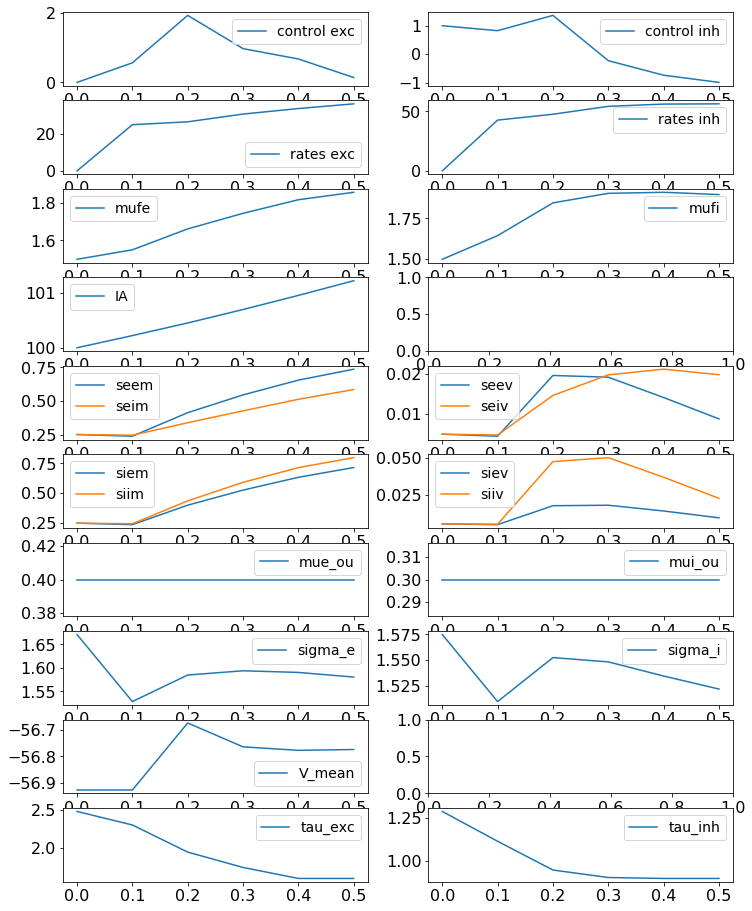

In [80]:
dur = 0.5

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,2] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

control1[0,1,2] += 1.
control1[0,1,:] += np.cos(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]
target[:,1,:] = a.state["rates_inh"][0,:]

fig, axes = plt.subplots(10,2, figsize=(12, 16))
axes[0,0].plot(a.t, control1[0,0,:], label="control exc")
axes[0,1].plot(a.t, control1[0,1,:], label="control inh")
axes[1,0].plot(a.t, a.state["rates_exc"][0,:], label="rates exc")
axes[1,1].plot(a.t, a.state["rates_inh"][0,:], label="rates inh")
axes[2,0].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[2,1].plot(a.t, a.state["mufi"][0,:], label="mufi")
axes[3,0].plot(a.t, a.state["IA"][0,:], label="IA")

axes[4,0].plot(a.t, a.state["seem"][0,:], label="seem")
axes[4,0].plot(a.t, a.state["seim"][0,:], label="seim")
axes[5,0].plot(a.t, a.state["siem"][0,:], label="siem")
axes[5,0].plot(a.t, a.state["siim"][0,:], label="siim")

axes[4,1].plot(a.t, a.state["seev"][0,:], label="seev")
axes[4,1].plot(a.t, a.state["seiv"][0,:], label="seiv")
axes[5,1].plot(a.t, a.state["siev"][0,:], label="siev")
axes[5,1].plot(a.t, a.state["siiv"][0,:], label="siiv")

axes[6,0].plot(a.t, a.state["mue_ou"][0,:], label="mue_ou")
axes[6,1].plot(a.t, a.state["mui_ou"][0,:], label="mui_ou")

axes[7,0].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[7,1].plot(a.t, a.state["sigmai_f"][0,:], label="sigma_i")
axes[8,0].plot(a.t, a.state["Vmean_exc"][0,:], label="V_mean")
axes[9,0].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
axes[9,1].plot(a.t, a.state["tau_inh"][0,:], label="tau_inh")

for i in range(10):
    for j in range(2):
        if ((i,j) != (3,1) and (i,j) != (8,1)):
            axes[i,j].legend()

print(target)
print(a.state["tau_exc"][0,:])

In [81]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.rates_inh_init,
                             a.params.mufe_init, a.params.mufi_init, a.params.IA_init,
                             a.params.seem_init, a.params.seim_init, a.params.siem_init, a.params.siim_init,
                             a.params.seev_init, a.params.seiv_init, a.params.siev_init, a.params.siiv_init,
                             a.params.mue_ou, a.params.mui_ou] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 40

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

err = False
for c in range(len(A1_costA)-1):
    if A1_costA[c] < A1_costA[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

set cost params
RUN  0 , total integrated cost =  8.621233461195404
too big control
too big control
too big control
RUN  1 , total integrated cost =  2.7649549847464714
too big control
too big control
RUN  2 , total integrated cost =  1.3035311014709063
too big control
too big control
RUN  3 , total integrated cost =  0.9158287306154551
too big control
RUN  4 , total integrated cost =  0.7986210904132308
RUN  5 , total integrated cost =  0.7530022703564396
RUN  6 , total integrated cost =  0.7302206875022051
RUN  7 , total integrated cost =  0.7186703586691688
RUN  8 , total integrated cost =  0.711813143410406
RUN  9 , total integrated cost =  0.7079719448831275
RUN  10 , total integrated cost =  0.7052945983943713
RUN  11 , total integrated cost =  0.7036239897998834
RUN  12 , total integrated cost =  0.7022780813800549
RUN  13 , total integrated cost =  0.7013916319441379
RUN  14 , total integrated cost =  0.7006135403531303
RUN  15 , total integrated cost =  0.7001149127923997
RUN 

 max iteration reached, step size =  1.410005408962875e-43
RUN  33 , total integrated cost =  0.6986869710780511
Control only changes marginally.
Improved over  33  iterations by  91.89574236421186  percent.
final gradient =  [[[ 0.          0.00801019 -0.0134181   0.00599051  0.00144047
    0.        ]
  [ 0.         -0.01189317 -0.00963695 -0.0100944  -0.00632516
    0.        ]]]
cost decreases throughout computation


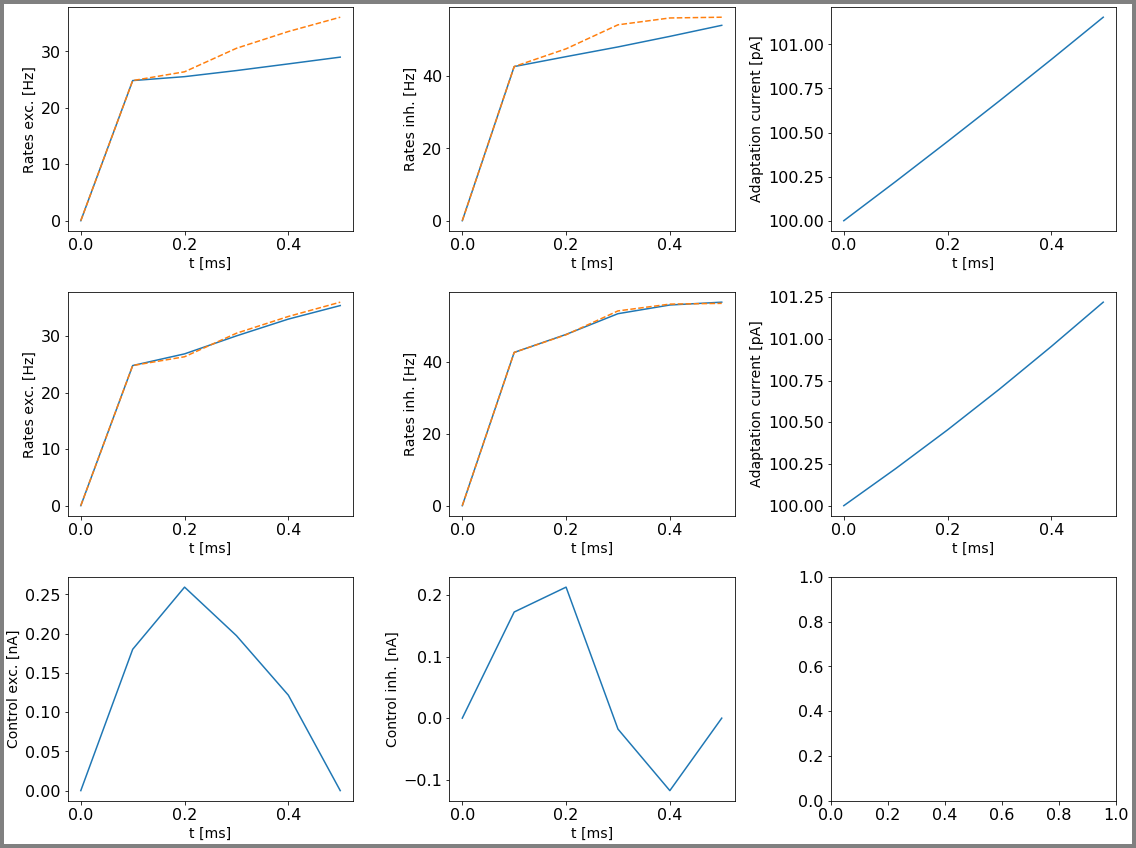

In [84]:
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a1')

In [85]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  8.621233461195404
RUN  1 , total integrated cost:  1.733367747783146
RUN  2 , total integrated cost:  0.9917031181409316
RUN  3 , total integrated cost:  0.8015800251015909
RUN  4 , total integrated cost:  0.7366824551520769
RUN  5 , total integrated cost:  0.7125960110857322
RUN  6 , total integrated cost:  0.7029876961042139
RUN  7 , total integrated cost:  0.6998981952997376
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
RUN  8 , total integrated cost:  0.6989839644852788
RUN  9 , total integrated cost:  0.6987360982670723
RUN  10 , total integrated cost:  0.6986751141457996
RUN  11 , total integrated cost:  0.698661765119664
change helped, counter =  2
change helped, counter =  2
RUN  12 , total integrated cost:  0.6986594722674534
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
RUN  13 , total integrated cost:  0.698658937403531
change helped, counter =  2
chang

[[[ 0.          0.90516198  1.30021221  0.98171474  0.60662097
    0.        ]
  [ 0.          0.85815218  1.06740639 -0.08806821 -0.5889766
    0.        ]]]


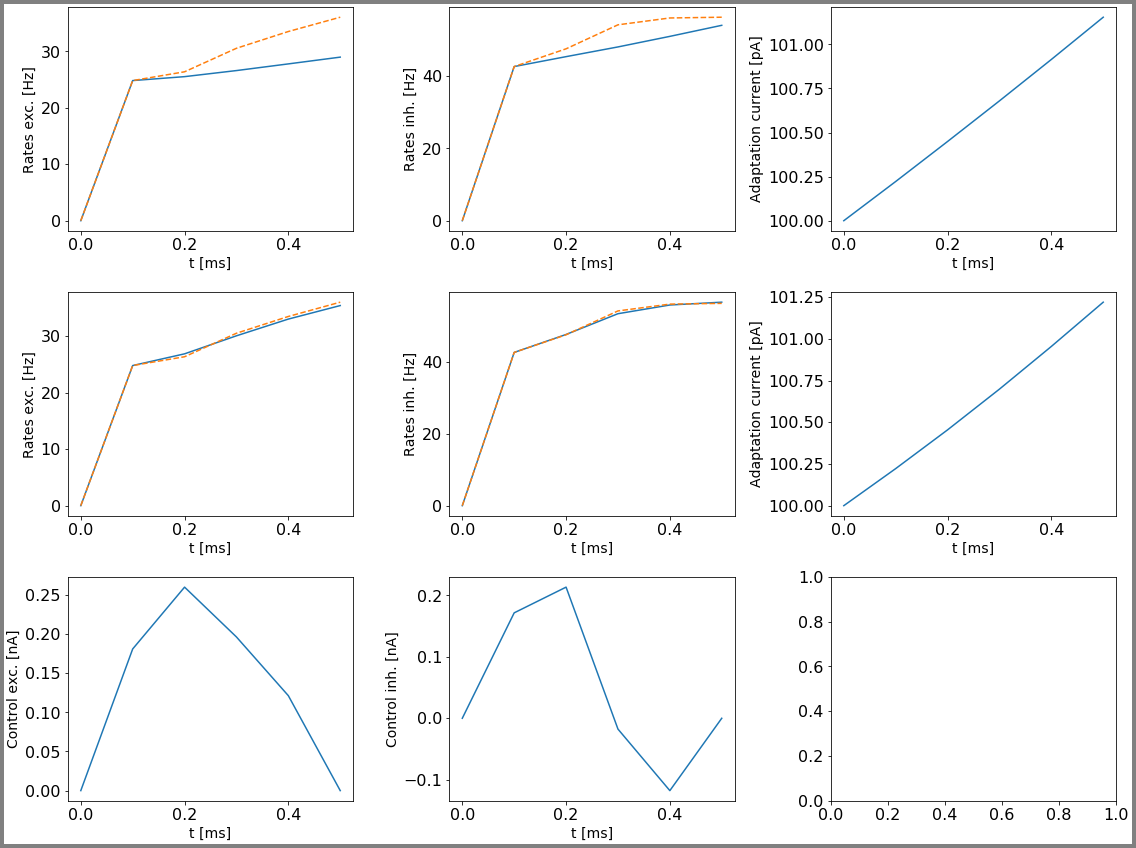

In [87]:
# 0.6986869710780511
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a1')

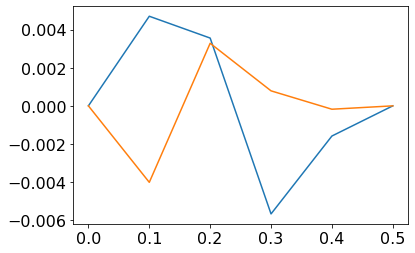

In [88]:
diff0 = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]
diff1 = A2_bestControlA[0,1,:] - A1_bestControlA[0,1,:]

plt.plot(a.t, diff0)
plt.plot(a.t, diff1)
plt.show()